# Hill Radius and Orbital Stability in the Solar System

This notebook presents a simplified computational analysis of gravitational
dominance regions around several solar system bodies using the Hill radius
approximation.

The study compares Earth, Mars, Jupiter, and the asteroid Bennu in order
to illustrate how gravitational influence scales with body mass.

The model evaluates the ratio between planetary gravity and solar gravity
as a function of distance, providing an approximate indicator of orbital
stability regions.

Author: Ömür Çarboğa

Method: Python numerical simulation

Year: 2026

## Method Overview

The model estimates gravitational dominance by comparing the gravitational force exerted by a celestial body with the gravitational force from the Sun at the same location. 

Distances are expressed as a fraction of the Hill radius, allowing the gravitational environments of different bodies to be compared using a normalized scale. The simulation evaluates this ratio across a range of distances and visualizes how gravitational influence changes for each body.
Units used in this simulation:

Distance = meters
Mass = kilograms
Hill radius = meters
Plots = Hill radius units

### Gravitational Force Ratio

The stability metric used in this simulation is the ratio between the
gravitational force from the secondary body and the gravitational force
from the Sun at the same location.

F = G M / r^2

Using this relation, the gravitational dominance ratio becomes:

Gravity Ratio = (G M_body / r_body^2) / (G M_sun / r_sun^2)

When the ratio is greater than 1, the gravitational influence of the
secondary body exceeds that of the Sun.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

"""
PHYSICAL ASSUMPTIONS:

1. The solar gravitational force is treated as constant across the Hill sphere.
   This assumes that the particle distance from the planet (r) is much smaller
   than the orbital radius of the planet (a), i.e., r << a.

2. Under this approximation, the particle–Sun distance is taken as approximately
   equal to the orbital radius (a), so solar gravity is computed as:

       F_sun = G * M / a^2

3. This is a first-order approximation valid within the Hill sphere.

NOTE:
A more precise model would use (a ± r), but this would slightly modify results
and is not necessary within the Hill-radius framework.
"""

"""
MODEL DESCRIPTION:

This simulation evaluates gravitational dominance by comparing the
gravitational force of a secondary body with that of the Sun.

The model:
- Computes instantaneous force ratios
- Does NOT simulate trajectories or time evolution
- Does NOT solve the three-body problem

Therefore, results represent gravitational dominance transitions,
not exact orbital stability boundaries.
"""

'\nMODEL DESCRIPTION:\n\nThis simulation evaluates gravitational dominance by comparing the\ngravitational force of a secondary body with that of the Sun.\n\nThe model:\n- Computes instantaneous force ratios\n- Does NOT simulate trajectories or time evolution\n- Does NOT solve the three-body problem\n\nTherefore, results represent gravitational dominance transitions,\nnot exact orbital stability boundaries.\n'

## Hill Radius Function

In [2]:
def hill_radius(a, m, M):
    """
    Calculates the Hill radius of a celestial body.

    The Hill radius defines the region where the gravitational
    influence of a planet dominates over the Sun.

    Parameters
    ----------
    a : float
        Orbital distance from the Sun (m)
    m : float
        Mass of the planet (kg)
    M : float
        Mass of the Sun (kg)

    Returns
    -------
    float
        Hill radius (m)
    """

    return a * (m / (3 * M)) ** (1/3)

### Hill Radius Definition

The Hill radius defines the approximate region around a celestial body where its gravitational influence dominates over perturbations from the Sun.

It can be estimated using:

R_H = a ( m / (3M) )^(1/3)

where

a  = orbital semi-major axis of the body  
m  = mass of the body  
M  = mass of the Sun

This approximation is widely used in celestial mechanics to estimate the region in which satellites may remain gravitationally bound to a planet.

## Physical Constants

In [3]:
# Physical Constants


G = 6.67430e-11        # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30       # mass of the Sun (kg)

# Planetary Data

jupiter_mass = 1.898e27    # kg
jupiter_orbit= 7.78e11     # m

earth_mass = 5.972e24      # kg
earth_orbit = 1.496e11     # m

mars_mass = 6.39e23        # kg
mars_orbit = 2.279e11      # m

# Asteroid Data

bennu_mass = 7.8e10        # kg
bennu_orbit = 1.68e11      # m

# NOTE:
# Bennu's mass is extremely small compared to planetary bodies.
# As a result, its Hill sphere and gravitational dominance region are extremely limited.
# The simulation therefore illustrates how gravitational influence strongly depends on body mass.

## Celestial Body Data

In [4]:
bodies = {
    "Jupiter": (
        jupiter_mass,
        jupiter_orbit,
        hill_radius(jupiter_orbit, jupiter_mass, M_sun)
    ),

    "Earth": (
        earth_mass,
        earth_orbit,
        hill_radius(earth_orbit, earth_mass, M_sun)
    ),

    "Mars": (
        mars_mass,
        mars_orbit,
        hill_radius(mars_orbit, mars_mass, M_sun)
    ),

    "Bennu": (
        bennu_mass,
        bennu_orbit,
        hill_radius(bennu_orbit, bennu_mass, M_sun)
    )
}

## Hill Radius Calculations

In [5]:
jupiter_hill = hill_radius(jupiter_orbit, jupiter_mass, M_sun)
earth_hill = hill_radius(earth_orbit, earth_mass, M_sun)
mars_hill = hill_radius(mars_orbit, mars_mass, M_sun)
bennu_hill = hill_radius(bennu_orbit, bennu_mass, M_sun)

print(f"Jupiter Hill Radius: {jupiter_hill:.2e} m")
print(f"Earth Hill Radius: {earth_hill:.2e} m")
print(f"Mars Hill Radius: {mars_hill:.2e} m")
print(f"Bennu Hill Radius: {bennu_hill:.2e} m")

Jupiter Hill Radius: 5.31e+10 m
Earth Hill Radius: 1.50e+09 m
Mars Hill Radius: 1.08e+09 m
Bennu Hill Radius: 3.96e+04 m


### Interpretation

The calculated Hill radii indicate the approximate gravitational dominance regions
of each body relative to the Sun. Larger bodies with greater mass possess larger
Hill spheres, allowing them to gravitationally retain satellites and nearby objects.

## Hill Radius Scale Comparison

To illustrate the large differences in gravitational influence between celestial bodies, the Hill radius of each body is compared directly.

This visualization highlights how planetary bodies possess far larger gravitational regions of influence than small asteroids such as Bennu.

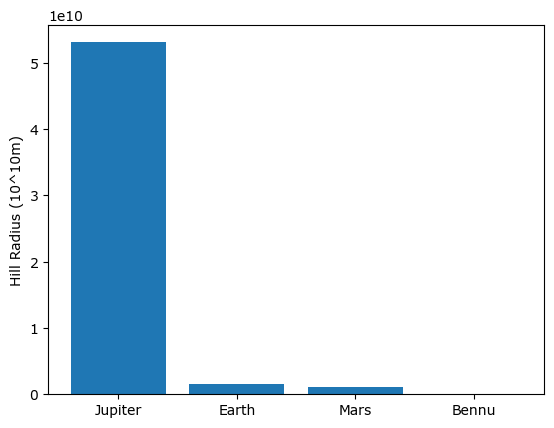

In [6]:
jupiter_hill_m = jupiter_hill
earth_hill_m = earth_hill
mars_hill_m = mars_hill
bennu_hill_m = bennu_hill

objects = ["Jupiter","Earth", "Mars", "Bennu"]
hill_values = [jupiter_hill_m, earth_hill_m, mars_hill_m, bennu_hill_m]

plt.figure()

plt.bar(objects, hill_values)

plt.ylabel("Hill Radius (10^10m)")
plt.savefig("hill_radius.png")

plt.show()

### Interpretation

The figure shows that Earth possesses the largest Hill sphere among the three studied bodies.
Mars has a smaller gravitational sphere of influence due to its lower mass.
The asteroid Bennu has an extremely small Hill region, reflecting the weak gravitational influence of small bodies.

## Orbital Stability Analysis

In [7]:
# Gravity Ratio Function
# This function calculates the ratio between the gravitational force
# from the celestial body and the gravitational force from the Sun
# at a given radial distance r.
#
# ratio > 1  → the body's gravity dominates locally
# ratio ≈ 1  → approximate transition between solar and planetary influence
# ratio < 1  → solar gravity dominates
#
# In the numerical analysis, a small tolerance is used when detecting
# the transition point because floating-point calculations rarely
# produce values exactly equal to 1.
def stability_ratio(r, m_planet, M_sun, a_planet, G):
    """
    Computes the ratio between planetary gravity and solar gravity
    at a distance r from the planet.

    Parameters
    ----------
    r : float
        Distance from planet (m)
    m_planet : float
        Mass of planet (kg)
    M_sun : float
        Mass of Sun (kg)
    a_planet : float
        Orbital distance of planet from Sun (m)
    G : float
        Gravitational constant

    Returns
    -------
    float
        Gravity ratio (planet gravity / solar gravity)
    """

    planet_gravity = G * m_planet / r**2
    solar_gravity = G * M_sun / a_planet**2

    return planet_gravity / solar_gravity

## Model Assumptions

This computational model evaluates gravitational dominance within the Hill sphere under several simplifying assumptions:

• The Sun–planet system is treated as a two-body system.  
• Perturbations from other planets are neglected.  
• Test particles are assumed to have negligible mass.  
• Circular planetary orbits are assumed.

These assumptions allow a simplified analysis of gravitational stability regions.

## Test Distances

In [8]:
x = np.linspace(0.01, 2.0, 2000)

### Radial Sampling Domain

The normalized radial coordinate `x` represents distance in units of the Hill radius.

Distances are sampled from **0.01 to 2 Hill radii** using 2000 evenly spaced points.  
This range allows the simulation to evaluate gravitational dominance both well inside the Hill sphere and slightly beyond it.

Sampling this interval provides a numerical profile of how the gravity ratio varies with distance from the planetary body.

### Simulation Method

This simulation analyzes gravitational stability around planetary bodies
using the Hill radius framework.

The model compares gravitational forces from the planetary body and
the Sun at different radial distances.

The stability metric is defined as:

Gravity Ratio = F_planet / F_sun

Distances are expressed in units of the Hill radius. The stability boundary is defined as the location where the gravity ratio drops below 1, meaning solar gravity becomes dominant.

Note: The gravity ratio threshold used in this simulation represents a simplified indicator of gravitational dominance. It should not be interpreted as a precise orbital stability boundary. True orbital stability is governed by the dynamical behavior of the Restricted Three-Body Problem.

Bodies analyzed in this simulation:

• Jupiter
• Earth
• Mars
• Asteroid (101955) Bennu

In [9]:
# MODEL LIMITATION NOTE
# This simulation evaluates a gravitational force ratio between the Sun and the secondary body.
# It is used here as a simplified indicator of gravitational dominance near the Hill radius.
# The model does NOT compute full orbital stability solutions.
# Real orbital stability is governed by the dynamics of the Restricted Three-Body Problem.
results = {}

for name, (mass, orbit, hill) in bodies.items():

    # Convert normalized distance to physical distance
    r = x * hill

    ratio = stability_ratio(
        r,
        mass,
        M_sun,
        orbit,
        G
    )

    results[name] = ratio

### Gravitational Dominance Transition Detection

To estimate the boundary of gravitational dominance, the simulation identifies the radial distance at which the gravitational force from the celestial body becomes equal to the gravitational force from the Sun.

This occurs when the gravity ratio

F_body / F_sun = 1

At this transition point, neither gravitational source dominates. Beyond this distance, solar perturbations begin to dominate over the body's gravity.

The algorithm therefore searches for the first location where the computed gravity ratio crosses unity. A small numerical tolerance is applied to avoid errors caused by floating-point precision.

In [10]:
# Finds the approximate location where the gravity ratio crosses unity.
def find_dominance_transition_radius(x, ratios):
    """
    Finds the approximate location where the gravity ratio crosses unity.
    A small numerical tolerance is used to account for floating-point precision.
    Returns the distance in Hill radius units.
    """

    tolerance = 1e-6

    for i in range(1, len(ratios)):
        if ratios[i] <= 1 + tolerance and ratios[i-1] > 1 + tolerance:
            return x[i]

    return None

In [11]:
transition_points = {}

for name, ratios in results.items():

    transition = find_dominance_transition_radius(x, ratios)

    transition_points[name] = transition

In [12]:
for body, transition in transition_points.items():

    if transition is None:
        print(f"{body}: No transition point detected within sampled range")

    else:
        print(f"{body} transition point ≈ {round(transition,3)} Hill radii")

Jupiter transition point ≈ 0.453 Hill radii
Earth transition point ≈ 0.173 Hill radii
Mars transition point ≈ 0.12 Hill radii
Bennu: No transition point detected within sampled range


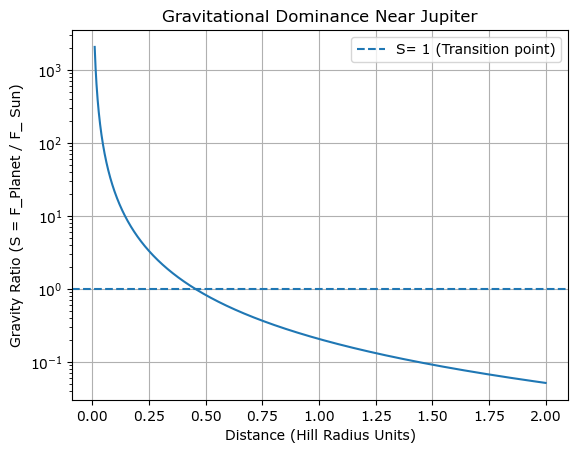

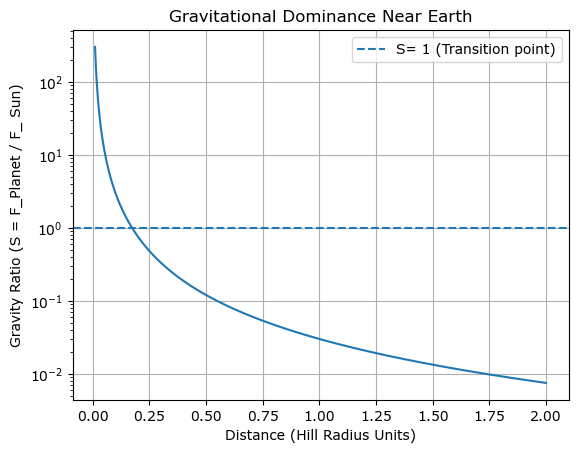

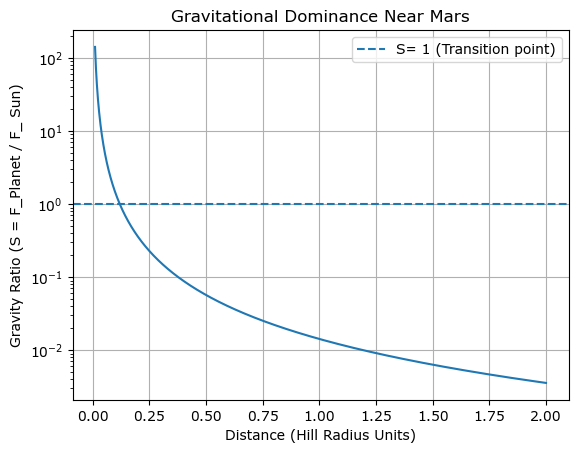

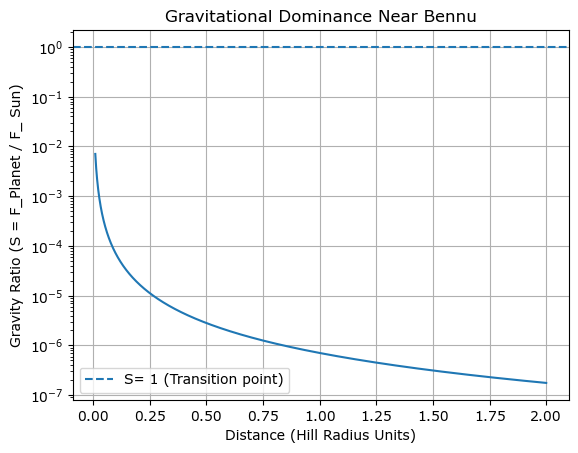

In [13]:
import matplotlib.pyplot as plt

for name, ratios in results.items():

    plt.figure()

    plt.plot(x, ratios)

    plt.axhline(1, linestyle="--", label="S= 1 (Transition point)")

    plt.yscale("log")

    plt.xlabel("Distance (Hill Radius Units)")
    plt.ylabel("Gravity Ratio (S = F_Planet / F_ Sun)")

    plt.title(f"Gravitational Dominance Near {name}")

    plt.grid(True)
    plt.legend()

    plt.savefig(f"{name}_stability_plot.png", dpi=300)
    plt.show()

In [14]:
import pandas as pd

rows = []

for name, (mass, orbit, hill) in bodies.items():
    rows.append({
        "Body": name,
        "Hill Radius (m)": hill,
        "Hill Radius (km)": hill / 1000
    })

df = pd.DataFrame(rows)

df.index = df.index + 1
df.index.name = "No."

df

,Body,Hill Radius (m),Hill Radius (km)
No.,,,
1,Jupiter,5.310796e+10,5.310796e+07
2,Earth,1.496418e+09,1.496418e+06
3,Mars,1.082246e+09,1.082246e+06
4,Bennu,3.957511e+04,3.957511e+01


## Stability Comparison

The figure below compares the gravitational dominance of each body as a function of distance normalized by its Hill radius.

The vertical axis represents the ratio between the gravitational acceleration produced by the body and the gravitational acceleration produced by the Sun at the same location. Values greater than one indicate that the gravitational influence of the body dominates over solar gravity, suggesting regions where stable satellite orbits may exist.

The dashed reference lines indicate:
• x = 1 Hill radius  
• gravitational ratio = 1 (equal solar and planetary influence)

The comparison illustrates the large differences in gravitational sphere of influence between planets and small bodies such as the asteroid Bennu.

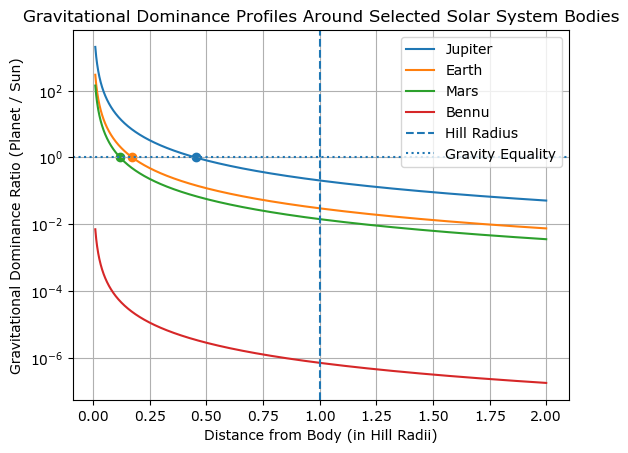

In [15]:
plt.figure()

for name, ratios in results.items():
    plt.plot(x, ratios, label=name)

for body, transition in transition_points.items():

    
  if transition is not None:
    plt.scatter(transition, 1)
        
plt.axvline(1, linestyle="--", label="Hill Radius")
plt.axhline(1, linestyle=":", label="Gravity Equality")

plt.yscale("log")

plt.xlabel("Distance from Body (in Hill Radii)")
plt.ylabel("Gravitational Dominance Ratio (Planet / Sun)")
plt.title("Gravitational Dominance Profiles Around Selected Solar System Bodies")

plt.legend()
plt.grid(True)

plt.savefig("comparative_behaviour.png")
plt.show()

### Stability Threshold Visualization

The horizontal dotted line represents the point at which the gravitational force of the celestial body equals the gravitational force exerted by the Sun. When the ratio exceeds unity, the body's gravity dominates locally.

Circular markers indicate the approximate locations where each body's gravitational dominance begins within the sampled domain.

## Quantitative Results

The table below summarizes the key numerical results produced by the computational model, including Hill radius size and the detected stability boundary for each body.

In [16]:
print("Body | Hill Radius (km) | Stability Boundary (R_H) | Transition (km)")
print("----------------------------------------------------------------")

for name, (mass, orbit, hill) in bodies.items():

    hill_km = hill
    transition_hr = transition_points[name]

    if transition_hr is not None:
        transition_km = transition_hr * hill_km

        print(
            f"{name} | {round(hill_km,2)} | {round(transition_hr,3)} | {round(transition_km,2)}"
        )

    else:
        print(
            f"{name} | {round(hill_km,2)} | No boundary (within 2 R_H) | No boundary (within 2 R_H)"
        )

Body | Hill Radius (km) | Stability Boundary (R_H) | Transition (km)
----------------------------------------------------------------
Jupiter | 53107964189.29 | 0.453 | 24057721806.89
Earth | 1496417737.09 | 0.173 | 259271777.51
Mars | 1082245857.02 | 0.12 | 129333523.15
Bennu | 39575.11 | No boundary (within 2 R_H) | No boundary (within 2 R_H)


### Interpretation of Bennu Result

The asteroid Bennu has an extremely small mass compared with planets such as Earth and Mars.

Because of this, solar gravity dominates almost everywhere near the asteroid. As a result, the gravity ratio rarely exceeds unity and a clear stability transition does not appear within the sampled range.

Within the evaluated interval (0.01–2 Hill radii), the gravity ratio does not cross the threshold value of one. Therefore, the algorithm cannot detect a gravitational dominance transition for Bennu.

This demonstrates how gravitational stability regions shrink rapidly for very low-mass bodies.

## Comparison with Real Satellite Systems

The results can be compared with known satellite systems in the Solar System.

Major moons typically orbit well inside their planet's Hill radius.  
For example, the Galilean moons of Jupiter orbit within a small fraction of Jupiter's Hill sphere.

This pattern is consistent with the simulation results: stable gravitational dominance regions generally occur within a fraction of the Hill radius rather than extending all the way to the Hill boundary.

The model therefore provides a simplified explanation for why large planets can maintain extensive satellite systems, while small bodies such as asteroids rarely possess stable moons.

## Discussion

The results highlight the strong dependence of gravitational influence on body mass across Solar System objects. Massive planets maintain large regions in which their gravity dominates over solar perturbations, enabling the existence of stable satellite systems.

The giant planet Jupiter exhibits the largest gravitational dominance region in the simulation due to its extremely large mass. Its Hill radius is significantly larger than those of terrestrial planets such as Earth and Mars, allowing Jupiter to maintain a very extensive region where its gravity dominates over solar perturbations. This large gravitational domain explains why Jupiter hosts a complex system of many natural satellites.Terrestrial planets such as Earth and Mars also maintain substantial gravitational regions where orbital motion can remain stable.

In contrast, the asteroid Bennu exhibits an extremely small region of gravitational dominance. Solar gravity dominates across most of the sampled domain, illustrating why long-term stable satellites are rare for very small bodies.

Overall, the comparison demonstrates how gravitational scaling shapes the dynamical environments surrounding planetary bodies and provides a useful framework for comparing orbital stability conditions across different celestial objects.

However, the Hill radius should be interpreted as an approximate indicator of gravitational influence. True orbital stability in a three-body system depends on long-term dynamical evolution rather than instantaneous gravitational force ratios.

## Model Limitations

This analysis uses a simplified gravitational force ratio to approximate
regions of gravitational dominance near the Hill radius.

The model does not perform full orbital integrations or solve the
restricted three-body problem. As a result, the identified stability
boundaries should be interpreted as approximate indicators rather than
precise dynamical stability limits.

More advanced analyses would require numerical N-body simulations that
track the long-term evolution of particle trajectories.

## Implications for Spacecraft Dynamics

Understanding gravitational dominance regions is important in spacecraft trajectory design. Space missions operating near planets or small bodies must consider the balance between solar gravity and the gravity of the local body. Within a planet's Hill sphere, spacecraft or natural satellites can remain gravitationally bound to the planet. For small bodies such as asteroids, the extremely small Hill spheres imply that spacecraft orbits are strongly affected by solar gravity. This is one reason why missions studying asteroids often use station-keeping or quasi-orbit trajectories rather than stable long-term orbits.

## Conclusion
This computational analysis examined how gravitational dominance varies with distance from a celestial body by comparing the gravitational influence of the body with that of the Sun. Using the concept of the Hill sphere, the simulation demonstrates how the size of gravitational stability regions scales strongly with body mass.

Terrestrial planets such as Earth and Mars exhibit clear transition regions where their gravitational influence becomes comparable to solar gravity, occurring near approximately 0.17 RH for Earth and 0.12 RH for Mars in the normalized model. In contrast, the asteroid 101955 Bennu shows extremely weak gravitational influence, with solar gravity dominating across the sampled region.

The giant planet Jupiter illustrates the opposite extreme: its large mass produces a vastly larger Hill sphere and a much broader region of gravitational dominance. Overall, the results highlight how the Hill radius provides a useful first-order approximation for comparing gravitational environments across Solar System bodies.
